<a href="https://colab.research.google.com/github/Kai-0224/Python/blob/main/chisquare_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

chi-square test


In [1]:
# Import the sys module
import sys
# Install necessary Python packages: pycbc, lalsuite, and ligo-common
# These libraries are commonly used in gravitational-wave data analysis.
# --no-cache-dir option prevents pip from using cached packages.
!{sys.executable} -m pip install pycbc lalsuite ligo-common --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 31.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 MB 174.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 156.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 308.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 212.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.7/182.7 kB 344.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 322.3 MB/s eta 0:00:00
   ━━━━━━

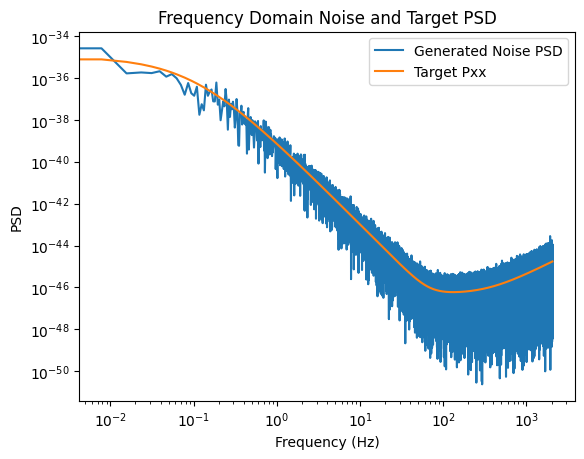

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data for demonstration (pure signal, noise, and combined signal)
# This part is not directly used in the later gravitational wave analysis but shows basic signal generation.
pure = np.linspace(-1, 1, 100)
noise = np.random.normal(0, 1, pure.shape)
signal = pure + noise

# Define parameters for gravitational wave data simulation
fs = 4096 # Sampling frequency (Hz)
l  = 128 # Segment length (seconds)

# Generate colored Gaussian noise in the frequency domain
flow = 30.0 # Lower frequency cutoff for noise generation
delta_f = 1.0 / fs # Frequency resolution
flen = int(2048 / delta_f) + 1 # Number of frequency bins
freqs = np.linspace(0,fs/2,fs*l//2+1) # Array of frequencies up to Nyquist frequency

# Define the Power Spectral Density (PSD) Pxx, representing the noise level at different frequencies
Pxx = (1.e-22*(18./(0.1+freqs))**2)**2+0.7e-23**2+((freqs/2000.)*4.e-23)**2

# Generate complex Gaussian noise 's' in the frequency domain based on the PSD Pxx
# This creates noise with the specified spectral shape.
s = np.sqrt(Pxx/2)*(np.random.randn(len(Pxx))+1.j*np.random.randn(len(Pxx)))

# Plot the generated noise PSD (absolute value squared of 's') and the target Pxx
# This helps to verify that the generated noise has the desired spectral characteristics.
plt.loglog(freqs,np.abs(s)**2, label='Generated Noise PSD')
plt.loglog(freqs,Pxx, label='Target Pxx')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Frequency Domain Noise and Target PSD')
plt.legend()
plt.show()

# Convert the frequency-domain noise 's' to the time domain 'st' using inverse real FFT
# The factor of 4 and trimming are specific to the simulation to get a stable segment.
st = 4.*np.fft.irfft(s)*fs
st = st[len(st)//4 : len(st)*3//4+1]*2

/usr/local/lib/python3.12/dist-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


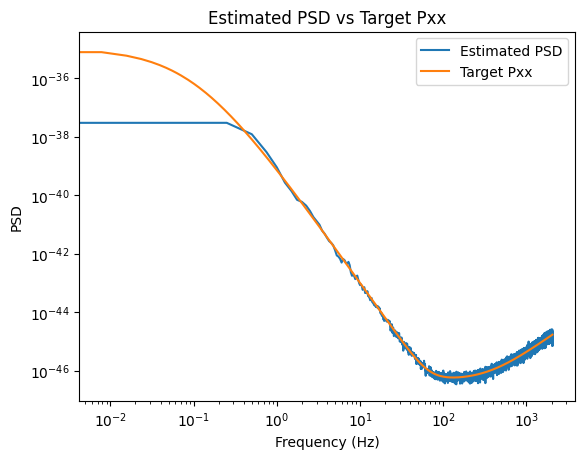

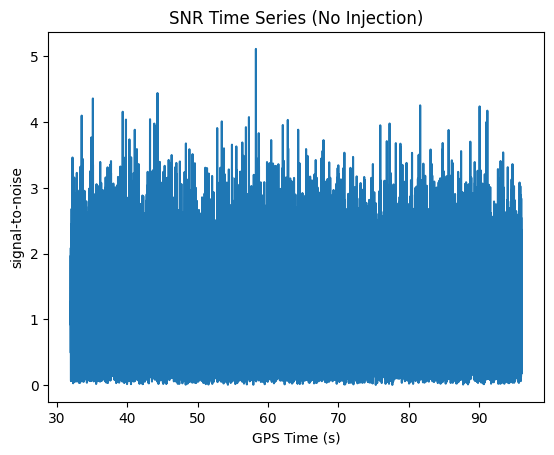

In [3]:
# Import modules from pycbc for waveform generation and matched filtering
from pycbc.waveform import get_fd_waveform
from pycbc.filter import highpass_fir, matched_filter
import matplotlib.mlab as mlab # Used for PSD estimation

# Estimate the Power Spectral Density (PSD) from the generated time-domain noise 'st'
df = freqs[1]-freqs[0] # Frequency bin width
# mlab.psd computes the PSD using Welch's method
psd ,psdfreq = mlab.psd(st, Fs = fs, NFFT = 4*fs, noverlap = 4*fs//2, detrend = "linear")
# Interpolate the estimated PSD to match the frequency array 'freqs'
psdin = np.interp(freqs ,psdfreq, psd)

# Plot the estimated PSD and the original target Pxx for comparison
plt.loglog(psdfreq,psd, label='Estimated PSD')
plt.loglog(freqs,Pxx, label='Target Pxx')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.title('Estimated PSD vs Target Pxx')
plt.legend()
plt.show()


# Generate a gravitational-wave inspiral waveform in the frequency domain (FD)
# Using IMRPhenomD approximant for black hole binary coalescence.
hp, hc = get_fd_waveform(approximant="IMRPhenomD", mass1=40, mass2=32,
                         f_lower=20, delta_f=1.0/l)

# Compute the Fast Fourier Transform (FFT) of the time-domain noise 'st'
s_f = np.fft.fft(st) / fs
# Resize the generated waveform template to match the length of the data's FFT
hp.resize(len(s_f))

# Perform matched filtering to calculate the Signal-to-Noise Ratio (SNR) time series
# Matched filtering involves correlating the data with the template, weighted by the PSD.
snrf = s_f.conjugate() * hp.data / psdin # Unnormalized matched filter output in frequency domain
snr  = 2*np.fft.ifft(snrf)*fs # Convert to time domain and apply normalization factors
# Calculate the squared optimal SNR (normalization factor for SNR time series)
sigmasq = 2*(hp.data * hp.data.conjugate() / psdin).sum()*df

# Remove regions corrupted by filter wraparound effects (artifacts from FFT)
snr = snr[len(snr) // 4: len(snr) * 3 // 4]/np.sqrt(np.abs(sigmasq))

# Plot the absolute value of the SNR time series
plt.plot(np.linspace(l/4,l*3/4,len(snr)),abs(snr))
plt.ylabel('signal-to-noise')
plt.xlabel('GPS Time (s)')
plt.title('SNR Time Series (No Injection)')
plt.show()

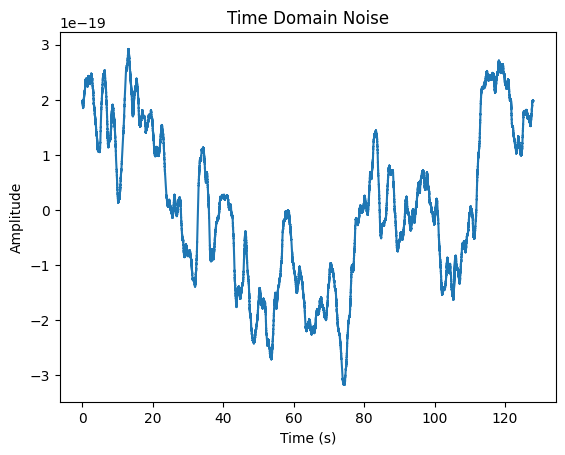

In [4]:
# Convert the frequency-domain noise 's' back to the time domain 'st' using inverse FFT
# This reconstructs the original time-domain noise from its frequency representation.
st = np.fft.ifft(s) * fs
st = 2.*st.real # Take the real part and scale

# Plot the time-domain noise
plt.plot(np.linspace(0,l,len(st)),st)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Time Domain Noise')
plt.show()

Text(0.5, 1.0, 'Time Domain Gravitational Waveform')

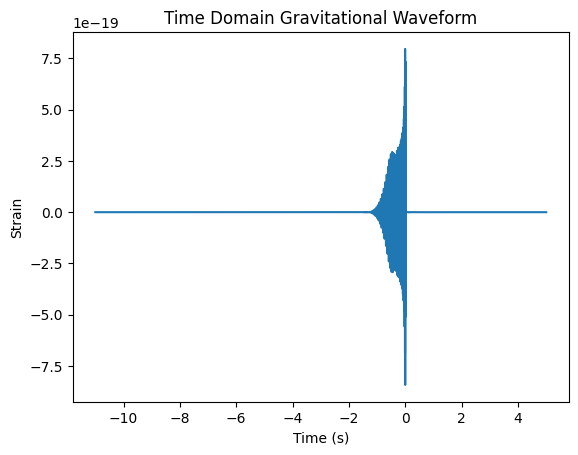

In [5]:
# Import function to generate time-domain waveforms from pycbc
from pycbc.waveform import get_td_waveform

# Generate a gravitational-wave inspiral waveform in the time domain (TD)
# Similar parameters to the FD waveform, but directly computed in time domain.
htp, htc = get_td_waveform(approximant="IMRPhenomD", mass1=40, mass2=32,
                         f_lower=20, delta_t=1./fs)

# Plot the time-domain plus polarization (htp) of the waveform
plt.plot(htp.sample_times,htp.data)
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title('Time Domain Gravitational Waveform')

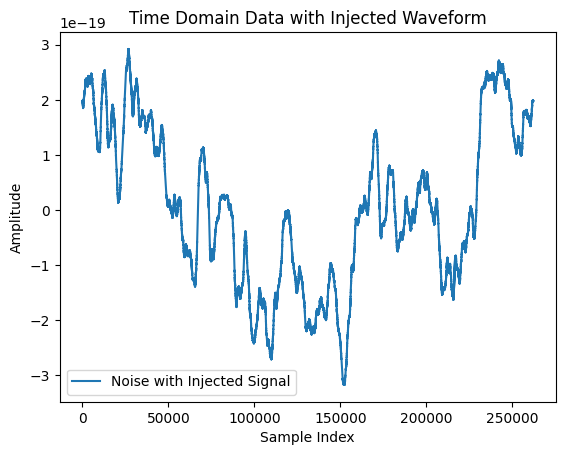

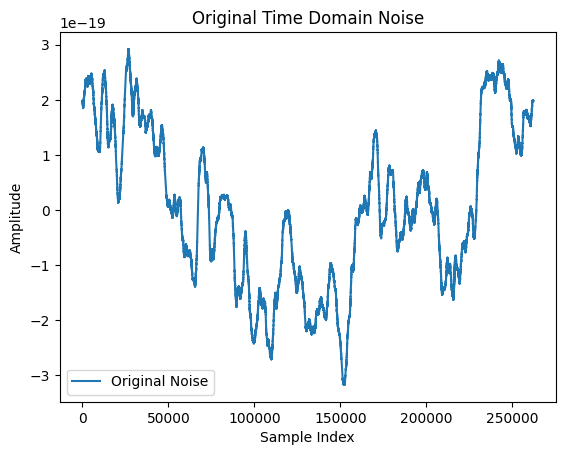

In [6]:
# Define a helper function to inject a signal (inj) into existing data (data)
# x specifies the starting index for injection, and order scales the injected signal.
def injection(data,inj,x,order):
  data_inj = np.array(data) # Create a copy of the data to avoid modifying the original
  for i in range(len(inj)): # Iterate through the injection signal
    data_inj[x+i] += inj[i]*order # Add the scaled injection to the data at the specified offset
  return data_inj


# Inject the time-domain waveform (htp.data) into the noise 'st'
# The waveform is injected in the middle of the noise segment with a scaling factor.
st_inj = injection( st, htp.data, len(st)//2, 1.e-3)

# Plot the data with the injected waveform
plt.plot(st_inj, label='Noise with Injected Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Time Domain Data with Injected Waveform')
plt.legend()
plt.show()

# Plot the original noise for comparison
plt.plot(st, label='Original Noise')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Original Time Domain Noise')
plt.legend()

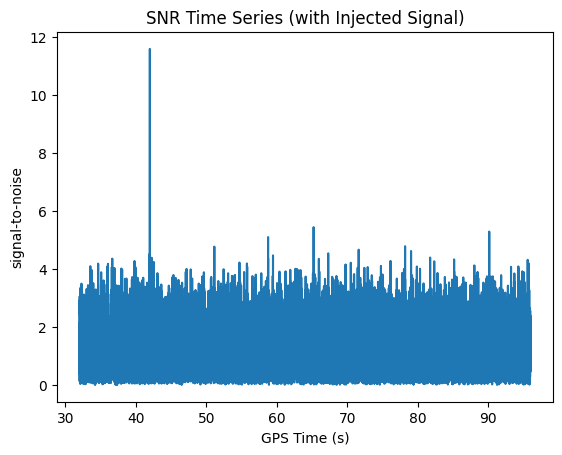

In [7]:

# Generate a gravitational-wave inspiral waveform in the frequency domain (FD) for matched filtering
# This template is used to search for the signal injected in the previous step.
hp, hc = get_fd_waveform(approximant="IMRPhenomD", mass1=40, mass2=32,
                         f_lower=20, delta_f=1.0/l)

# Compute the Fast Fourier Transform (FFT) of the data containing the injected signal
s_f = np.fft.fft(st_inj) / fs
# Resize the template to match the length of the data's FFT
hp.resize(len(s_f))

# Perform matched filtering to calculate the SNR time series on data with injected signal
# The sigmasq is calculated based on the template and PSD.
sigmasq = 1*(hp.data * hp.data.conjugate() / psdin).sum()*df
snrf = s_f.conjugate() * hp.data / psdin # Unnormalized matched filter output in frequency domain
snr  = 2*np.fft.ifft(snrf)*fs/np.sqrt(np.abs(sigmasq)) # Normalized SNR in time domain

# Remove regions corrupted by filter wraparound effects
snr = snr[len(snr) // 4: len(snr) * 3 // 4]

# Plot the absolute value of the SNR time series
plt.plot(np.linspace(l/4,l*3/4,len(snr)),abs(snr))
plt.ylabel('signal-to-noise')
plt.xlabel('GPS Time (s)')
plt.title('SNR Time Series (with Injected Signal)')
plt.show()

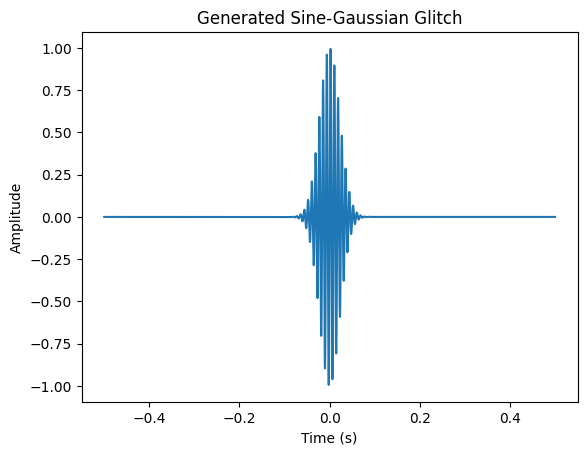

In [8]:
fx = 120. # Central frequency of the sine-Gaussian glitch

# Generate a time array for the glitch
x = np.linspace(-1./2,1./2,fs*2)
# Create a sine-Gaussian glitch waveform
glitch = np.sin(2.*np.pi*fx*x)*np.exp(-1.e3*x*x)

# Plot the generated glitch waveform
plt.plot(x,glitch)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Generated Sine-Gaussian Glitch')
plt.show()

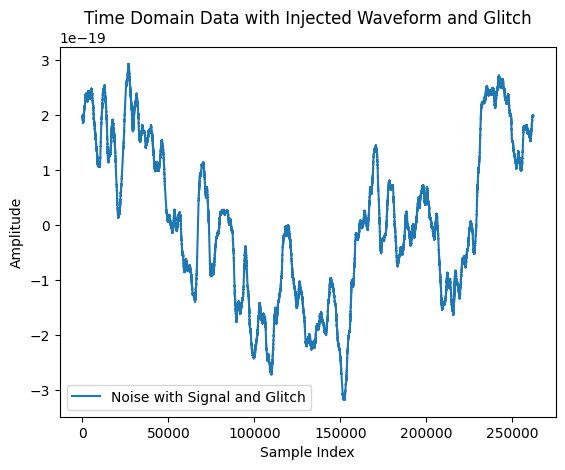

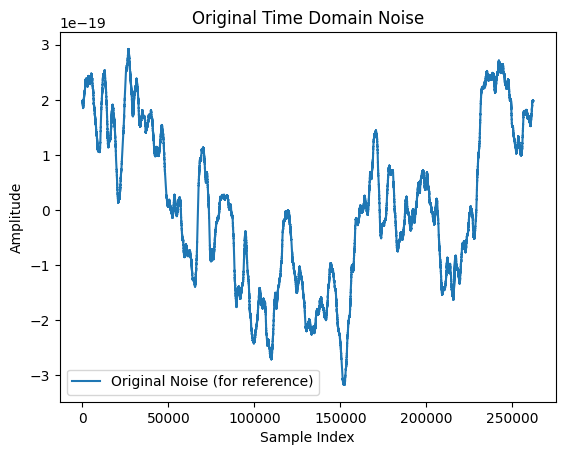

In [9]:
# Inject the generated glitch into the data that already contains the signal (st_inj)
# The glitch is injected at a different location from the signal, with a specific scaling.
st_glitch = injection(st_inj,glitch,len(st_inj)//2-fs*4,5.e-21)

# Plot the data containing both the injected signal and the glitch
plt.plot(st_glitch, label='Noise with Signal and Glitch')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Time Domain Data with Injected Waveform and Glitch')
plt.legend()
plt.show()

# Plot the original noise for comparison (already includes the signal from previous injection)
plt.plot(st, label='Original Noise (for reference)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Original Time Domain Noise')
plt.legend()

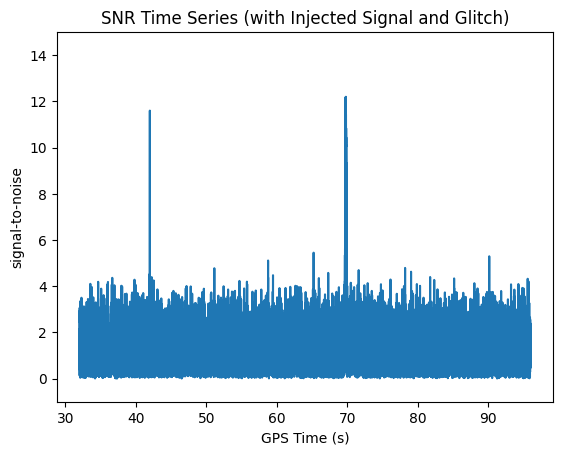

In [10]:

# Generate a frequency-domain waveform template for matched filtering
hp, hc = get_fd_waveform(approximant="IMRPhenomD", mass1=40, mass2=32,
                         f_lower=20, delta_f=1.0/l)

# Compute the FFT of the data containing both the signal and the glitch
s_f = np.fft.fft(st_glitch) / fs
# Resize the template to match the length of the data's FFT
hp.resize(len(s_f))

# Perform matched filtering on data with both signal and glitch
sigmasq = 1*(hp.data * hp.data.conjugate() / psdin).sum()*df
snrf = s_f.conjugate() * hp.data / psdin
snr  = 2*np.fft.ifft(snrf)*fs/np.sqrt(np.abs(sigmasq))

# Remove regions corrupted by filter wraparound effects
snr = snr[len(snr) // 4: len(snr) * 3 // 4]

# Create a time array corresponding to the trimmed SNR
time = np.linspace(l/4,l*3/4,len(snr))

# Store the absolute value of the SNR (often referred to as 'z_all' in GW analysis)
z_all = abs(snr)

# Plot the absolute value of the SNR time series, showing peaks for both signal and glitch
plt.plot(time,abs(snr))
plt.ylim(-1,15) # Set y-axis limits for better visualization
plt.ylabel('signal-to-noise')
plt.xlabel('GPS Time (s)')
plt.title('SNR Time Series (with Injected Signal and Glitch)')
plt.show()

Using chi-square method to discard glitch.

ref :

https://arxiv.org/pdf/gr-qc/0509116.pdf

https://journals.aps.org/prd/pdf/10.1103/PhysRevD.71.062001

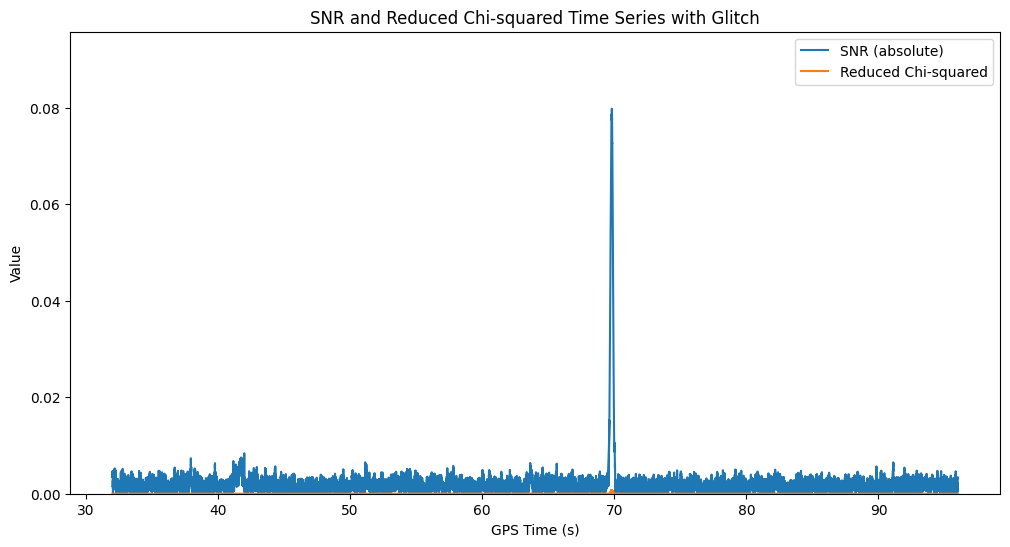

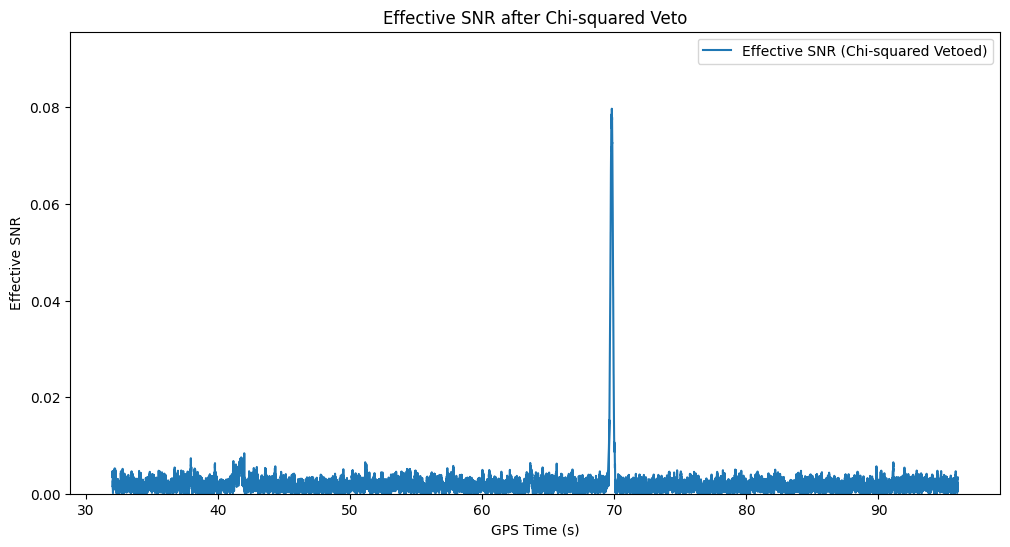

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for chi-squared calculation
p_bins = 5 # Number of frequency bins to split the template. Must be > 1.

# Check if p_bins is valid for a meaningful chi-squared calculation
if p_bins <= 1:
    print("Error: p_bins must be greater than 1 for meaningful chi-squared calculation. Setting chi2 to 0.")
    # Fallback if p_bins is invalid, set chi_squared_reduced to zeros.
    # snr_full_complex might not be defined yet, this is a placeholder.
    chi_squared_reduced = np.zeros_like(snr_full_complex)
else:
    # Re-interpolate the estimated PSD to match the full FFT length of the data for consistency
    freqs_for_fft = np.fft.fftfreq(len(st_glitch), d=1.0/fs)
    psd_for_s_f = np.interp(np.abs(freqs_for_fft), psdfreq, psd)
    # Avoid division by zero in PSD by setting very small values to a minimum threshold
    psd_for_s_f = np.where(psd_for_s_f < 1e-40, 1e-40, psd_for_s_f)

    # Get the full template (hp.data) and data FFT (s_f) for calculations
    hp_data_full = hp.data
    s_f_data_full = s_f

    # Calculate overall SNR related quantities for the full template (without binning)
    # sigmasq_full_val is the squared optimal SNR denominator: <h|h>
    sigmasq_full_val = (hp_data_full * np.conjugate(hp_data_full) / psd_for_s_f).sum() * df
    # snrf_full is the unnormalized matched filter output for the full template
    snrf_full = np.conjugate(s_f_data_full) * hp_data_full / psd_for_s_f
    # snr_full_complex is the complex SNR time series for the full template
    snr_full_complex = 2 * np.fft.ifft(snrf_full) * fs

    # Normalize the full SNR time series for plotting later
    # Handle potential division by zero for sigmasq_full_val by setting a safe minimum
    sigmasq_full_val_safe = np.where(sigmasq_full_val == 0, 1e-40, sigmasq_full_val)
    snr_normalized_full = snr_full_complex / np.sqrt(np.abs(sigmasq_full_val_safe))

    # Define frequency range relevant to the template
    f_lower_template = 20.0 # Lower frequency cutoff for waveform generation
    f_upper_template = fs / 2.0 # Nyquist frequency (upper limit for template)

    # Find indices in `freqs_for_fft` that fall within the active template frequency range
    # This ensures only relevant frequencies are considered for binning.
    positive_freq_slice = np.where(freqs_for_fft >= 0)[0] # Get indices of positive frequencies
    active_freq_range_indices = positive_freq_slice[
        (freqs_for_fft[positive_freq_slice] >= f_lower_template) &
        (freqs_for_fft[positive_freq_slice] <= f_upper_template)
    ]

    # Adjust p_bins if the number of active frequency points is too small for the requested bins
    if len(active_freq_range_indices) < p_bins:
        original_p_bins = p_bins
        p_bins = max(2, len(active_freq_range_indices)) # Need at least 2 bins for (p_bins-1) in denominator
        if p_bins == original_p_bins:
            print(f"Warning: Not enough active frequency points to create {original_p_bins} bins. Using {p_bins} bins.")
        else:
            print(f"Warning: Not enough active frequency points to create {original_p_bins} bins. Adjusted p_bins to {p_bins}.")
        if p_bins <= 1:
            print("Error: After adjustment, p_bins is still <= 1. Cannot compute chi-squared.")
            chi_squared_reduced = np.zeros_like(snr_full_complex) # Fallback if adjustment fails
            p_bins = 0 # Indicate no valid bins

    if p_bins > 1: # Proceed with chi-squared calculation if p_bins is valid
        # Determine the bin edges in terms of indices within the active frequency range
        bin_edge_indices_in_active = np.linspace(0, len(active_freq_range_indices), p_bins + 1).astype(int)

        # Initialize a variable to accumulate terms for the chi-squared sum
        sum_chi2_terms = np.zeros(len(st_glitch), dtype=complex) # Sum of |C_k|^2 / <h_k|h_k>

        # Loop through each frequency bin to calculate its contribution to chi-squared
        for k_bin in range(p_bins):
            hp_k = np.zeros_like(hp_data_full, dtype=complex) # Initialize sub-template for the current bin

            # Get the global indices corresponding to the current frequency bin
            global_indices_pos = active_freq_range_indices[bin_edge_indices_in_active[k_bin] : bin_edge_indices_in_active[k_bin+1]]

            # Populate the sub-template hp_k with data from the full template for the current bin
            hp_k[global_indices_pos] = hp_data_full[global_indices_pos]

            # Ensure conjugate symmetry for `hp_k` for proper `ifft`
            # For real-valued time-domain signals, the FFT is conjugate symmetric.
            # We need to explicitly set negative frequency components based on positive ones.
            non_zero_pos_indices = global_indices_pos[global_indices_pos != 0]
            global_indices_neg = (len(st_glitch) - non_zero_pos_indices) % len(st_glitch)

            if len(non_zero_pos_indices) > 0:
                hp_k[global_indices_neg] = np.conjugate(hp_data_full[non_zero_pos_indices])
            if 0 in global_indices_pos: # Handle DC component if present in the bin
                hp_k[0] = hp_data_full[0]

            # Calculate sigma_k_sq for this segment: <h_k|h_k> (optimal SNR denominator for this bin)
            sigmasq_k_val = (hp_k * np.conjugate(hp_k) / psd_for_s_f).sum() * df
            sigmasq_k_val_safe = np.where(sigmasq_k_val == 0, 1e-40, sigmasq_k_val) # Ensure not zero

            # Calculate unnormalized matched filter output for this bin: C_k(t) = <s|h_k>
            snrf_k = np.conjugate(s_f_data_full) * hp_k / psd_for_s_f
            snr_k_complex = 2 * np.fft.ifft(snrf_k) * fs

            # Add term to the chi-squared sum: |C_k(t)|^2 / <h_k|h_k>
            sum_chi2_terms += np.abs(snr_k_complex)**2 / sigmasq_k_val_safe

        # Calculate the reduced chi-squared statistic as per standard definition
        # chi_r^2(t) = (1 / (2*(p_bins-1))) * ( sum_{k=1}^{p_bins} (|C_k(t)|^2 / <h_k|h_k>) - (|C_0(t)|^2 / <h_0|h_0>) )
        # This formula compares the sum of squared SNRs from individual bins to the squared SNR from the full template.
        # Handle potential division by zero for the denominator terms (already done by sigmasq_full_val_safe).
        snr_full_abs_sq_over_sigmasq_full = np.abs(snr_full_complex)**2 / sigmasq_full_val_safe

        chi_squared_reduced = (1.0 / (2.0 * (p_bins - 1.0))) * (sum_chi2_terms - snr_full_abs_sq_over_sigmasq_full)
        chi_squared_reduced = np.real(chi_squared_reduced) # Chi-squared is a real-valued statistic
        chi_squared_reduced = np.maximum(0, chi_squared_reduced) # Chi-squared should always be non-negative
    else: # p_bins was <= 1 after adjustment, so no valid chi-squared could be computed
        chi_squared_reduced = np.zeros_like(snr_full_complex)


# Apply filter wraparound trimming to both chi_squared_reduced and SNR time series
# This removes artifacts from the FFT operations at the beginning and end of the segment.
snr_full_length = len(snr_normalized_full)
trim_start = snr_full_length // 4
trim_end = snr_full_length * 3 // 4

chi_squared_trimmed = chi_squared_reduced[trim_start : trim_end]
snr_trimmed = np.abs(snr_normalized_full)[trim_start : trim_end]

# Plot the absolute SNR and the Reduced Chi-squared values over time
plt.figure(figsize=(12, 6))
plt.plot(time, snr_trimmed, label='SNR (absolute)')
plt.plot(time, chi_squared_trimmed, label='Reduced Chi-squared')
plt.ylabel('Value')
plt.xlabel('GPS Time (s)')
plt.title('SNR and Reduced Chi-squared Time Series with Glitch')
plt.legend()
# Set dynamic y-limit to accommodate both SNR and chi-squared values for better visibility
plt.ylim(0, max(np.max(snr_trimmed), np.max(chi_squared_trimmed)) * 1.2)
plt.grid(False)
plt.show()

# Calculate and plot Effective SNR using the chi-squared veto method
# Effective SNR is generally calculated as SNR / sqrt(1 + chi_squared_reduced).
# This effectively down-weights events that have high chi-squared values (i.e., poor template matches, like glitches).
# Adding 1 to the denominator ensures numerical stability (avoids division by zero if chi_squared_reduced is exactly 0).
effective_snr = snr_trimmed / np.sqrt(chi_squared_trimmed + 1)

plt.figure(figsize=(12, 6))
plt.plot(time, effective_snr, label='Effective SNR (Chi-squared Vetoed)')
plt.ylabel('Effective SNR')
plt.xlabel('GPS Time (s)')
plt.title('Effective SNR after Chi-squared Veto')
plt.legend()
# Set y-limit based on the maximum effective SNR
plt.ylim(0, np.max(effective_snr) * 1.2)
plt.grid(False)
plt.show()